# House pricing

Este notebook corresponde a una práctica de regresión de Kaggle vinculada a los precios de propiedades en función de sus características.

## Análisis y preprocesamiento

In [333]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [334]:
data = pd.read_csv("./train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [335]:
data.shape

(1460, 81)

In [336]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [337]:
data.isna().sum().values

array([   0,    0,    0,  259,    0,    0, 1369,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,  872,    8,    0,    0,    0,   37,   37,   38,
         37,    0,   38,    0,    0,    0,    0,    0,    0,    1,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,  690,   81,   81,   81,    0,    0,   81,   81,    0,
          0,    0,    0,    0,    0,    0, 1453, 1179, 1406,    0,    0,
          0,    0,    0,    0])

In [338]:
# columnas con valores faltantes
columns_with_na = data.columns[data.isnull().any()].tolist()
columns_with_na

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [339]:
data[columns_with_na].dtypes

,0
LotFrontage,float64
Alley,object
MasVnrType,object
MasVnrArea,float64
BsmtQual,object
BsmtCond,object
BsmtExposure,object
BsmtFinType1,object
BsmtFinType2,object
Electrical,object


Tenemos datos faltantes en columnas tanto categóricas como numéricas.

Podemos elegir una estrategia de imputación diferente según el tipo de dato de cada columna.

Probaremos la imputación por medio de SimpleImputer para columnas categóricas, y por medio de KNNImputer para las numéricas.

In [340]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [341]:
na_num_cols = data[columns_with_na].select_dtypes(include=['number', 'float64', 'int64']).columns.to_list()
na_cat_cols = data[columns_with_na].select_dtypes(include=['object']).columns.to_list()
cat_columns = data.select_dtypes(include=['object']).columns.to_list()

In [342]:
# Se deben escalar los datos para usar con KNNImputer
data_scaled = data.copy()
scaler = MinMaxScaler()
data_scaled[na_num_cols] = scaler.fit_transform(data_scaled[na_num_cols])
data_scaled.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,0.150685,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,0.202055,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,0.160959,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,0.133562,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,0.215753,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [343]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", KNNImputer(n_neighbors=5), na_num_cols),
        ("cat", SimpleImputer(strategy="most_frequent"), na_cat_cols)
    ],
    remainder="passthrough",  # Mantiene las demás columnas sin cambios
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [344]:
transformed_data = preprocessor.fit_transform(data_scaled)
transformed_data = transformed_data[data.columns]
transformed_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,0.150685,8450,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500
1,2,20,RL,0.202055,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500
2,3,60,RL,0.160959,11250,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500
3,4,70,RL,0.133562,9550,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000
4,5,60,RL,0.215753,14260,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000


In [345]:
# retornamos al rango original
transformed_data[na_num_cols] = scaler.inverse_transform(transformed_data[na_num_cols])
transformed_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000


In [346]:
transformed_data.isna().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [347]:
transformed_data = pd.get_dummies(transformed_data, columns=cat_columns, drop_first=True)

'''
category_cols = transformed_data.select_dtypes(include=['object']).columns.to_list()

for c in category_cols:
  le = LabelEncoder()
  transformed_data[c]= le.fit_transform(transformed_data[c].values)
'''
transformed_data

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,False,True,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,False,True,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,False,False,True,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,False,True,False,False,False,True,False


<ipython-input-348-2240e1a6063e>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(transformed_data['SalePrice'])


<Axes: xlabel='SalePrice', ylabel='Density'>

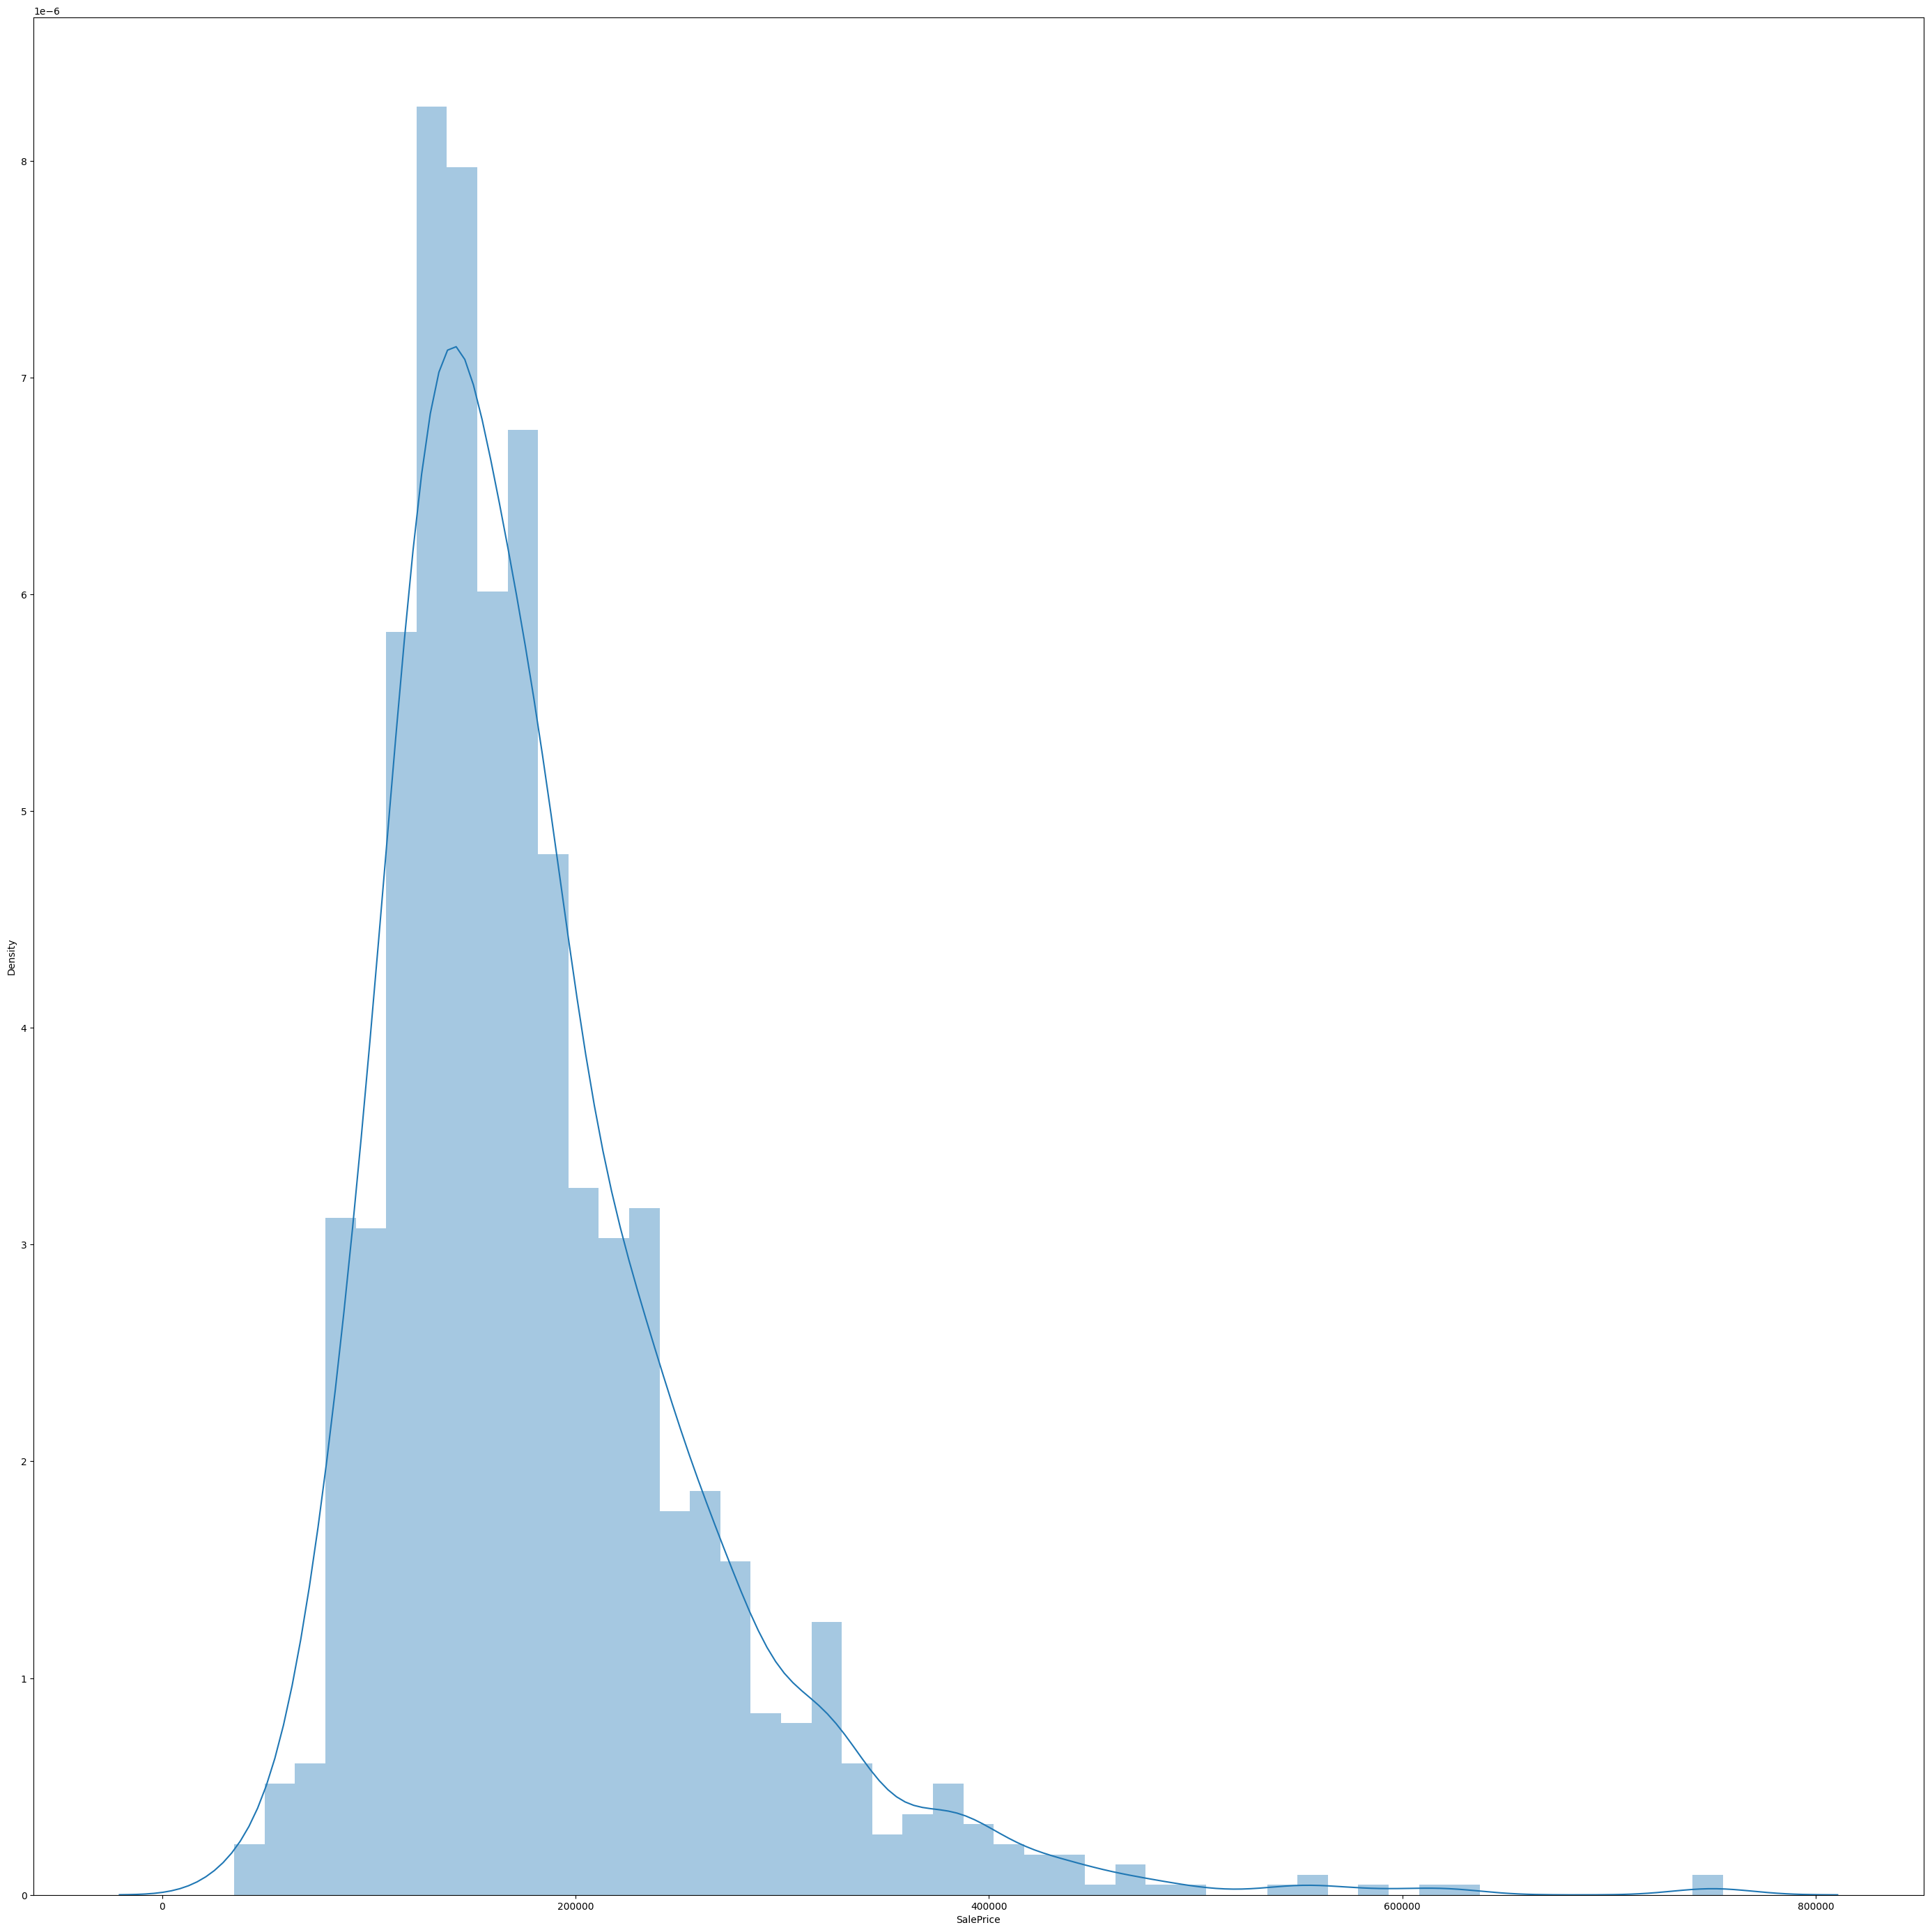

In [348]:
sns.distplot(transformed_data['SalePrice'])

## Entrenamiento del modelo

In [349]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, r2_score

In [350]:
X = transformed_data.drop(columns=["SalePrice", "Id"], axis=1)
y = transformed_data["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [351]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [352]:
pca = PCA()
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

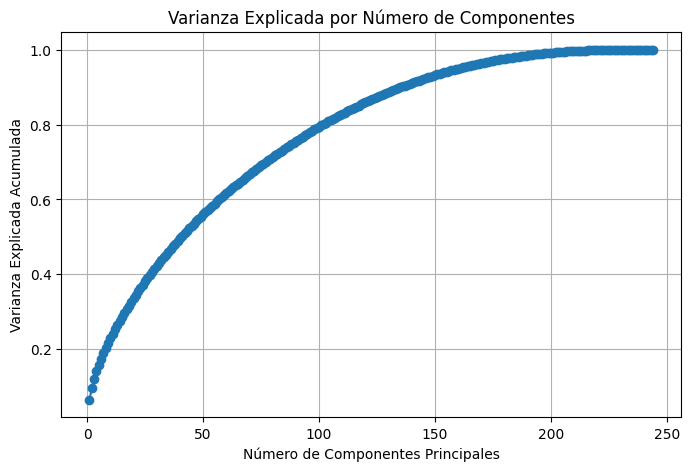

In [353]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por Número de Componentes')
plt.grid()
plt.show()

In [354]:
regressor = XGBRegressor()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [355]:
root_mean_squared_error(y_test, y_pred)

39587.97265625

In [356]:
y.max(), y.min()

(755000, 34900)

In [357]:
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape * 100:.2f}%")  # Expresado en porcentaje

R² Score: 0.8285
MAPE: 12.11%


## Probando con distintos modelos

In [358]:
models = {
    "XGBoost": {
        "model": XGBRegressor(objective="reg:squarederror", random_state=42),
        "params": {
            "n_estimators": [10, 50],
            "max_depth": [3, 8],
            "learning_rate": [0.01, 0.1]
        }
    },

    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [10, 50],
            "max_depth": [5, 10]
        }
    },

    "Ridge": {
        "model": Ridge(),
        "params": {
            "alpha": [0.1, 1.0, 10.0]
        }
    }
}

# Diccionario para almacenar resultados
results = {}

# Bucle sobre los modelos
for name, model_info in models.items():
    print(f"\nEntrenando modelo: {name}")

    grid_search = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    # Guardar resultados
    results[name] = {
        "best_score": -grid_search.best_score_,  # Convertimos a positivo
        "best_params": grid_search.best_params_,
        "best_estimator": grid_search.best_estimator_
    }

    print(f"Mejor RMSE para {name}: {results[name]['best_score']:.2f}")
    print(f"Mejores hiperparámetros: {results[name]['best_params']}")

# Encontrar el mejor modelo
best_model = min(results, key=lambda x: results[x]["best_score"])
print(f"\nEl mejor modelo es: {best_model} con RMSE de {results[best_model]['best_score']:.2f}")



Entrenando modelo: XGBoost
Mejor RMSE para XGBoost: 33007.55
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Entrenando modelo: RandomForest
Mejor RMSE para RandomForest: 33795.99
Mejores hiperparámetros: {'max_depth': 10, 'n_estimators': 50}

Entrenando modelo: Ridge
Mejor RMSE para Ridge: 38142.44
Mejores hiperparámetros: {'alpha': 10.0}

El mejor modelo es: XGBoost con RMSE de 33007.55


In [359]:
model = results[best_model]["best_estimator"]
y_pred = model.predict(X_test)
root_mean_squared_error(y_test, y_pred), y.max(), y.min()

(40868.83203125, 755000, 34900)

In [360]:
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape * 100:.2f}%")  # Expresado en porcentaje

R² Score: 0.8172
MAPE: 12.83%


### Confeccionando el Pipeline para generalización

## Generando predicciones de archivo de prueba